In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [42]:
df = pd.read_csv("dataset/netflix_cleaned.csv")

df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8797 non-null   str  
 1   type          8797 non-null   str  
 2   title         8797 non-null   str  
 3   director      8797 non-null   str  
 4   cast          8797 non-null   str  
 5   country       8797 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8797 non-null   int64
 8   rating        8797 non-null   str  
 9   duration      8797 non-null   str  
 10  listed_in     8797 non-null   str  
 11  description   8797 non-null   str  
dtypes: int64(1), str(11)
memory usage: 824.8 KB


Data Preparation


In [43]:
# Convert duration to numeric
df["duration_num"] = df["duration"].astype(str).str.extract("(\d+)")
df["duration_num"] = pd.to_numeric(df["duration_num"], errors="coerce")
df["duration_num"] = df["duration_num"].fillna(df["duration_num"].median())

# Select features
features = ["release_year", "duration_num", "rating", "country", "listed_in"]

data = df[features].copy()

# Fill missing values
data["country"] = data["country"].fillna("Unknown")
data["rating"] = data["rating"].fillna("Unknown")
data["listed_in"] = data["listed_in"].fillna("Unknown")

# One Hot Encoding
data = pd.get_dummies(data)

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

print("Data Prepared Successfully!")

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\USER\AppData\Local\Temp\ipykernel_12420\1740335407.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df["duration_num"] = df["duration"].astype(str).str.extract("(\d+)")


Data Prepared Successfully!


Elbow Method

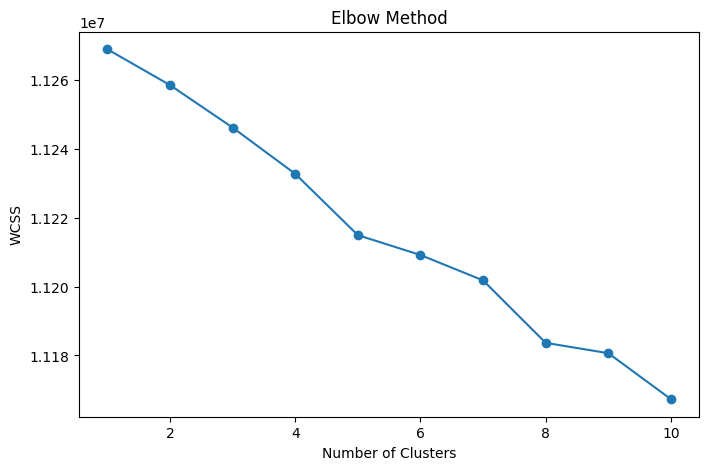

In [44]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

k-Means Clustering

In [45]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

print(df[["title","Cluster"]].head())

                   title  Cluster
0   Dick Johnson Is Dead        3
1          Blood & Water        0
2              Ganglands        0
3  Jailbirds New Orleans        0
4           Kota Factory        0


Cluster Summary

In [46]:
print("===== Cluster Summary =====")

for cluster in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster}")

    cluster_data = df[df["Cluster"] == cluster]

    print(cluster_data["type"].value_counts())

    print("\nTop Countries")
    print(cluster_data["country"].value_counts().head())

    print("\nTop Genres")
    print(cluster_data["listed_in"].value_counts().head())

    

===== Cluster Summary =====

Cluster 0
type
TV Show    1884
Movie       412
Name: count, dtype: int64

Top Countries
country
Unknown           540
United States     415
Japan             218
South Korea       160
United Kingdom     90
Name: count, dtype: int64

Top Genres
listed_in
Kids' Tv                                             219
Children & Family Movies                             166
International Tv Shows, Tv Dramas                    121
Crime Tv Shows, International Tv Shows, Tv Dramas    110
Kids' Tv, Tv Comedies                                 98
Name: count, dtype: int64

Cluster 1
type
TV Show    1
Name: count, dtype: int64

Top Countries
country
United Kingdom, United States, Czech Republic    1
Name: count, dtype: int64

Top Genres
listed_in
British Tv Shows, Docuseries, Science & Nature Tv    1
Name: count, dtype: int64

Cluster 2
type
TV Show    13
Name: count, dtype: int64

Top Countries
country
Thailand     2
Canada       2
Jordan       1
Australia    1
Italy    

PCA Visualization

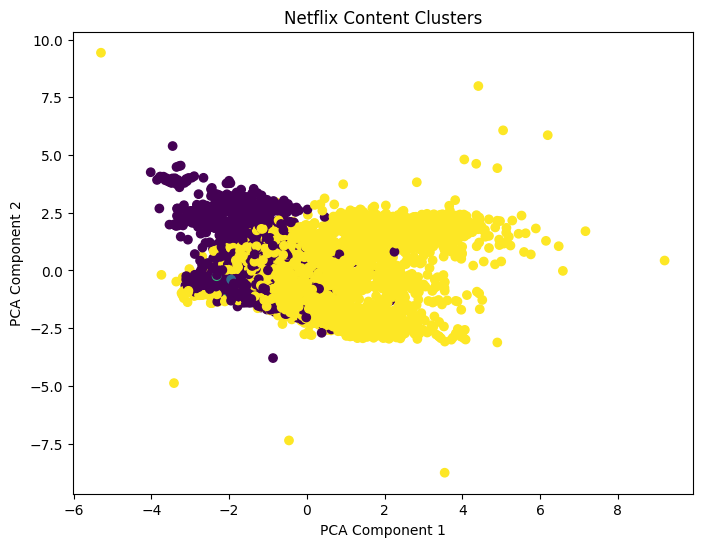

In [47]:
pca = PCA(n_components=2)

components = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("Netflix Content Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Random Forest Classification

In [48]:
X = data
y = df["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

Accuracy: 0.9988636363636364

Classification Report
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1229
     TV Show       1.00      1.00      1.00       531

    accuracy                           1.00      1760
   macro avg       1.00      1.00      1.00      1760
weighted avg       1.00      1.00      1.00      1760


Confusion Matrix
[[1227    2]
 [   0  531]]


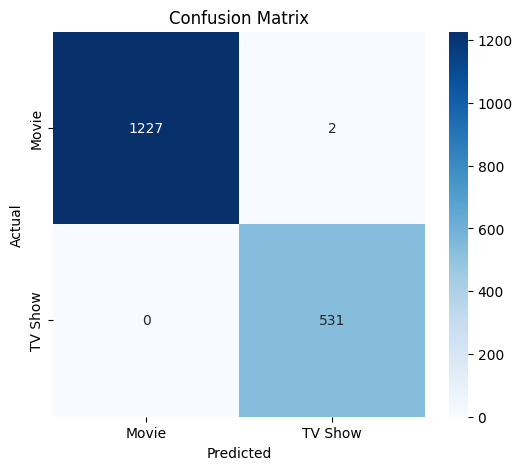

In [49]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

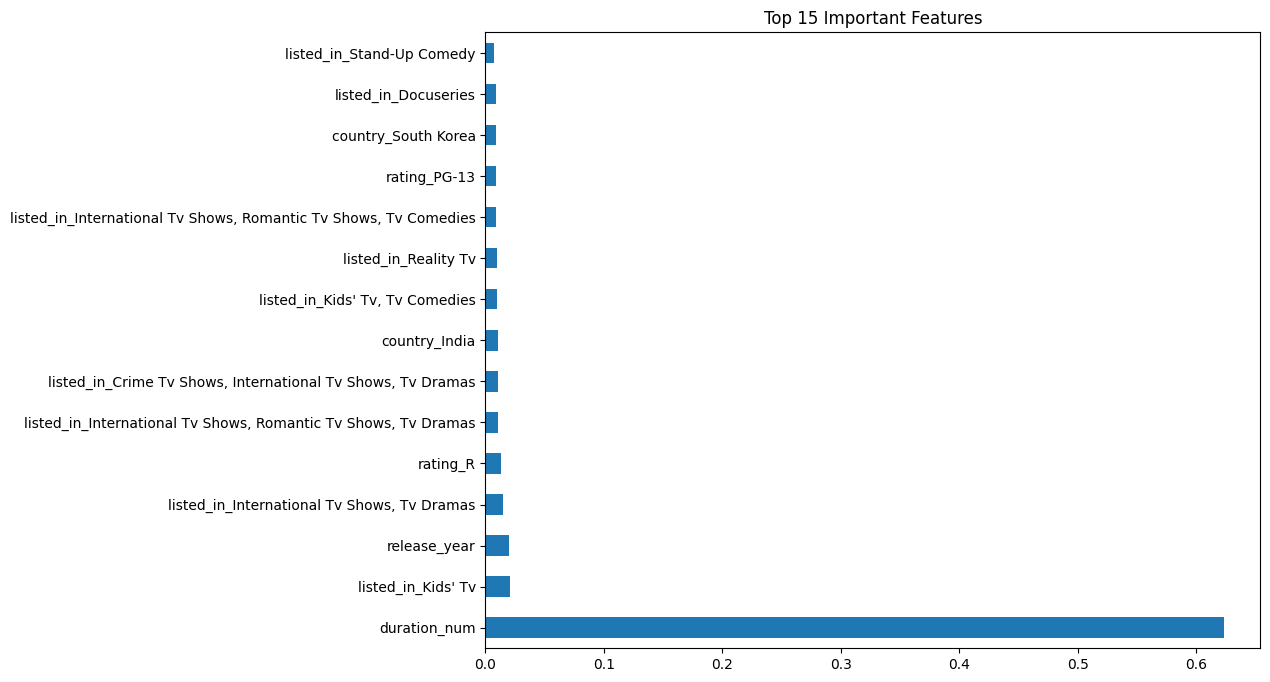

duration_num                                                        0.622882
listed_in_Kids' Tv                                                  0.020783
release_year                                                        0.019794
listed_in_International Tv Shows, Tv Dramas                         0.014399
rating_R                                                            0.013442
listed_in_International Tv Shows, Romantic Tv Shows, Tv Dramas      0.010484
listed_in_Crime Tv Shows, International Tv Shows, Tv Dramas         0.010446
country_India                                                       0.010153
listed_in_Kids' Tv, Tv Comedies                                     0.009842
listed_in_Reality Tv                                                0.009557
listed_in_International Tv Shows, Romantic Tv Shows, Tv Comedies    0.009003
rating_PG-13                                                        0.008973
country_South Korea                                                 0.008831

In [50]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.show()

print(importance.head(15))

In [52]:
df.to_csv("netflix_milestone3.csv", index=False)

print("Milestone 3 Completed Successfully!")

Milestone 3 Completed Successfully!
